<a href="https://colab.research.google.com/github/luisferojedat/claimai-policy-analyzer/blob/main/Actividad1_MLP_LFOT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FashionMNIST · MLP

### Actividad 1 · Clasificación inteligente de prendas mediante Perceptrón Multicapa

Diseño, entrenamiento y evaluación de una red MLP para clasificar las
10 categorías de FashionMNIST, utilizando validación independiente y
análisis posterior de las predicciones.

**Dataset** FashionMNIST  ·  **Modelo** MLP  ·  **Clases** 10  ·  **Entrada** 28×28

In [59]:
# importamos la libreria pytorch
import copy
import torch
from torch import nn
from torch import optim #las funciones de optimizacion (gradient descent)
from torch.optim.lr_scheduler import StepLR #learning rate decay
import torch.nn.functional as F #convencion
from torchvision import datasets, transforms

# matplotlib para pintar graficas
import matplotlib.pyplot as plt
from IPython.display import display, HTML

%matplotlib inline

In [60]:
# Paleta de colores estilo Apple para una estética minimalista y limpia
APPLE_BLUE = '#007AFF'
APPLE_GREEN = '#34C759'
APPLE_RED = '#FF3B30'
APPLE_GRAY = '#8E8E93'
APPLE_LIGHT = '#F5F5F7'


## 01 · Dataset

FashionMNIST contiene imágenes de prendas de 28×28 píxeles en escala de
gris. Los datos se separan en entrenamiento, validación y test para
distinguir aprendizaje, selección del modelo y evaluación final.

In [61]:
# usamos la GPU si esta disponible
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo usado: GPU con CUDA")
else:
  device = torch.device("cpu")
  print("Dispositivo usado: CPU")

Dispositivo usado: CPU


In [62]:
# Definir una transformación para convertir la imagen a un tensor
transform = transforms.Compose([
    transforms.ToTensor(), # hay que convertir a tensor los datos
    transforms.Normalize((0.2860,), (0.3530,)) # normalizacion del dataset
])

# Descargar el dataset FashionMNIST de articulos de ropa (entrenamiento completo y test)
dataset_full_train = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
dataset_test = datasets.FashionMNIST('data', train=False, download=True, transform=transform)

In [63]:
# la media y desviacion del dataset son los valores por los que se normaliza
# es buena idea normalizar el dataset para ayudar a que converja mas rapido
print("media: ", dataset_full_train.data.float().mean()/255)
print("desviacion: ", dataset_full_train.data.float().std()/255)

media:  tensor(0.2860)
desviacion:  tensor(0.3530)


In [64]:
# Dividir el dataset de entrenamiento completo en conjuntos de entrenamiento y validación
split_generator = torch.Generator().manual_seed(42)

dataset_train, dataset_validation = torch.utils.data.random_split(
    dataset_full_train,
    [54000, 6000],
    generator=split_generator
)

In [65]:
# tamaño del mini-batch
batch_size = 64

# generamos los dataloaders que se usaran para leer
# las imagenes el entrenamiento, validación y test
train_loader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = torch.utils.data.DataLoader(
    dataset_validation,
    batch_size=batch_size,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False
)

# categoria de ropa que corresponde a cada numero
desc = [
    'Camiseta/top',
    'Pantalón',
    'Jersey',
    'Vestido',
    'Abrigo',
    'Sandalia',
    'Camisa',
    'Zapatilla',
    'Bolso',
    'Bota'
]

### Resumen del Dataset

<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TRAIN</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">54.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">6.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">10.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CLASES</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">10</p>
    </div>
</div>

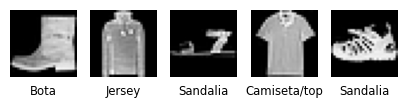

In [66]:
# primero, vemos unas imagenes del set de entrenamiento con sus etiquetas (labels)
figure = plt.figure(figsize=(5, 1))

# configurar tamaño de texto para las graficas
plt.rc('font', size=7)

for i in range(0,5):
  figure.add_subplot(1, 5, i+1)
  img, label = dataset_train[i]

  # img tiene dimensiones [1,28,28], squeeze() destruye las dimensiones de tamaño 1
  plt.imshow(img.squeeze(), cmap='Greys_r')
  plt.axis('off')
  plt.title(desc[label], y=-0.4)

## 02 · Modelo

Una red Perceptrón Multicapa transforma los 784 valores de cada imagen
mediante tres capas ocultas hasta obtener una distribución de probabilidad
sobre las 10 categorías.

In [67]:
input_size = 784
output_size = 10
hidden_sizes = [512, 256, 128]

In [68]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()
        self.layers = nn.ModuleList()

        # Input layer to first hidden layer
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))

        # Subsequent hidden layers
        for i in range(len(hidden_sizes) - 1):
            self.layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))

        # Last hidden layer to output layer
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))

        self.activation = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # Flatten the image input
        x = x.view(x.size(0), -1)

        for i, layer in enumerate(self.layers):
            x = layer(x)

            if i < len(self.layers) - 1: # Apply ReLU to all but the last layer (output layer)
                x = self.activation(x)
            else: # Apply Softmax only to the output layer
                x = self.softmax(x)
        return x

In [69]:
torch.manual_seed(42)

model = MLP(input_size, hidden_sizes, output_size).to(device)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nParámetros entrenables: {total_params:,}")

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
  (activation): ReLU()
  (softmax): Softmax(dim=1)
)

Parámetros entrenables: 567,434


In [70]:
html_panel = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ARQUITECTURA</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">784 → 512 → 256 → 128 → 10</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CAPAS OCULTAS</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">3</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ACTIVACIÓN</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">ReLU</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">SALIDA</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">Softmax</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">PARÁMETROS</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{total_params:,}</p>
    </div>
</div>
"""
display(HTML(html_panel))

28×28 → 784 → 512 · ReLU → 256 · ReLU → 128 · ReLU → 10 · Softmax

Muestra de predicciones iniciales (antes de entrenamiento):


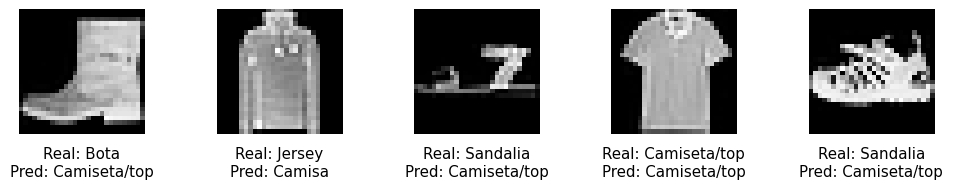

In [71]:
print('Muestra de predicciones iniciales (antes de entrenamiento):')

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculations
    for i in range(5):
        figure.add_subplot(1, 5, i + 1)
        img, label = dataset_train[i]

        # Prepare input for the model: add batch dimension, flatten, move to device
        input_img = img.view(1, 28 * 28).to(device)

        # Get model predictions
        output = model(input_img)
        predicted_class = torch.argmax(output).item()

        plt.imshow(img.squeeze(), cmap='Greys_r')
        plt.axis('off')
        plt.title(f"Real: {desc[label]}\nPred: {desc[predicted_class]}", y=-0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 03 · Entrenamiento

Los pesos se optimizan mediante SGD. Tras cada epoch, el conjunto de
validación mide la capacidad de generalización y permite conservar el mejor
estado de la red.

In [72]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    for batch_idx, (data, target) in enumerate(loader):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        data = data.view(data.shape[0], 28 * 28) # Flatten image
        output = model(data)
        target_onehot = F.one_hot(
            target,
            num_classes=10
        ).float()
        loss = F.mse_loss(
            output,
            target_onehot
        )
        loss.backward()
        optimizer.step()
        loss_training.append(loss.item())

In [73]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total_loss = 0.0
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            data = data.view(data.shape[0], 28 * 28) # Flatten image
            output = model(data)
            target_onehot = F.one_hot(
                target,
                num_classes=10
            ).float()
            total_loss += F.mse_loss(
                output,
                target_onehot,
                reduction='sum'
            ).item()
            pred = output.argmax(dim=1) # Get the index of the max log-probability
            correct += (pred == target).sum().item()

    total_loss /= len(loader.dataset) * 10 # IMPORTANT: multiply by 10 for avg loss per item
    accuracy = 100.0 * correct / len(loader.dataset)
    errors = len(loader.dataset) - correct
    return total_loss, accuracy, errors

In [74]:
# Evaluación inicial del modelo sin entrenar
initial_val_loss, initial_val_accuracy, initial_val_errors = evaluate(model, validation_loader)

html_panel_initial_eval = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">VALIDACIÓN INICIAL</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy: {initial_val_accuracy:.2f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Loss: {initial_val_loss:.4f}</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Errores: {initial_val_errors:,}</p>
    </div>
</div>
"""
display(HTML(html_panel_initial_eval))

In [75]:
# Reinicialización definitiva del modelo y preparación para el entrenamiento
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Re-crear el modelo para asegurar el mismo estado inicial antes del entrenamiento
model = MLP(input_size, hidden_sizes, output_size).to(device)

# Listas para guardar el historial de métricas
loss_training = []
train_loss_history = []
validation_loss_history = []
train_accuracy_history = []
validation_accuracy_history = []
lr_history = []

# Variables para guardar el mejor modelo
best_validation_accuracy = -1.0
best_validation_loss = None
best_train_accuracy = None
best_train_loss = None
best_epoch = 0
best_model_state = None

# Hiperparámetros
lr = 0.5
gamma = 0.9
epochs = 20

optimizer = optim.SGD(
    model.parameters(),
    lr=lr
)

scheduler = StepLR(
    optimizer,
    step_size=1,
    gamma=gamma
)

print("Comenzando el entrenamiento...")
for epoch in range(1, epochs + 1):
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    train_one_epoch(model, train_loader, optimizer)

    train_loss, train_accuracy, _ = evaluate(model, train_loader)
    validation_loss, validation_accuracy, _ = evaluate(model, validation_loader)

    train_loss_history.append(train_loss)
    validation_loss_history.append(validation_loss)
    train_accuracy_history.append(train_accuracy)
    validation_accuracy_history.append(validation_accuracy)

    # Guardar el mejor modelo si la precisión de validación mejora
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_validation_loss = validation_loss
        best_train_accuracy = train_accuracy
        best_train_loss = train_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} · Train {train_accuracy:.2f}% · Validation {validation_accuracy:.2f}% · Val Loss {validation_loss:.4f}")

assert best_model_state is not None, "No se encontró el mejor estado del modelo."
model.load_state_dict(best_model_state)

print("Entrenamiento completado.")

Comenzando el entrenamiento...
Epoch 01/20 · Train 81.20% · Validation 80.83% · Val Loss 0.0281
Epoch 02/20 · Train 84.66% · Validation 83.83% · Val Loss 0.0231
Epoch 03/20 · Train 86.71% · Validation 85.52% · Val Loss 0.0211
Epoch 04/20 · Train 87.30% · Validation 85.67% · Val Loss 0.0205
Epoch 05/20 · Train 87.99% · Validation 86.60% · Val Loss 0.0192
Epoch 06/20 · Train 87.19% · Validation 85.63% · Val Loss 0.0203
Epoch 07/20 · Train 89.64% · Validation 87.85% · Val Loss 0.0178
Epoch 08/20 · Train 89.35% · Validation 87.40% · Val Loss 0.0182
Epoch 09/20 · Train 90.36% · Validation 88.17% · Val Loss 0.0171
Epoch 10/20 · Train 90.06% · Validation 87.88% · Val Loss 0.0176
Epoch 11/20 · Train 91.12% · Validation 88.48% · Val Loss 0.0167
Epoch 12/20 · Train 91.39% · Validation 88.67% · Val Loss 0.0165
Epoch 13/20 · Train 90.88% · Validation 88.32% · Val Loss 0.0172
Epoch 14/20 · Train 91.82% · Validation 88.62% · Val Loss 0.0166
Epoch 15/20 · Train 91.92% · Validation 88.68% · Val Loss 0

## 04 · Validación

El conjunto de validación selecciona el estado del modelo que mejor
generaliza sin utilizar todavía los datos reservados para test.

In [76]:
# Verificación de los históricos
assert len(train_loss_history) == epochs
assert len(validation_loss_history) == epochs
assert len(train_accuracy_history) == epochs
assert len(validation_accuracy_history) == epochs
assert len(lr_history) == epochs

print("Históricos verificados correctamente.")

Históricos verificados correctamente.


In [77]:
generalization_gap = best_train_accuracy - best_validation_accuracy

html_panel_dashboard = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_validation_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST EPOCH</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_epoch} / {epochs}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TRAIN AT BEST</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_train_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">GENERALIZATION GAP</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{generalization_gap:.2f} pp</p>
    </div>
</div>
"""
display(HTML(html_panel_dashboard))

# Nivel de rúbrica
if best_validation_accuracy > 89:
    print("PRECISIÓN · SOBRESALIENTE\nValidation Accuracy > 89 %")
elif best_validation_accuracy > 85:
    print("PRECISIÓN · ACEPTABLE")
else:
    print("PRECISIÓN · MEJORABLE")

PRECISIÓN · SOBRESALIENTE
Validation Accuracy > 89 %


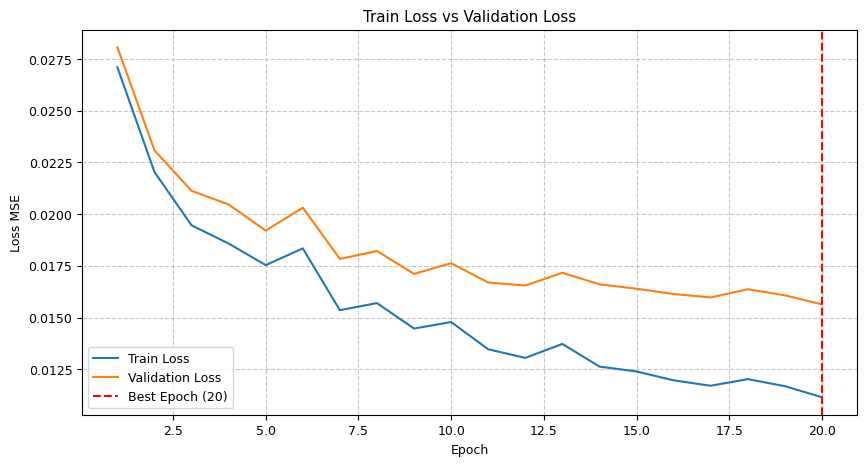

In [78]:
# Gráfica 1: Train Loss vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, epochs + 1), validation_loss_history, label='Validation Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Train Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

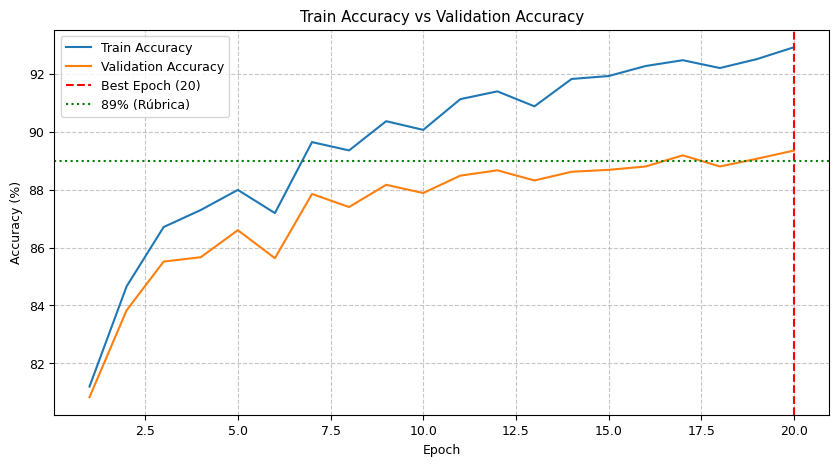

In [79]:
# Gráfica 2: Train Accuracy vs Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracy_history, label='Train Accuracy')
plt.plot(range(1, epochs + 1), validation_accuracy_history, label='Validation Accuracy')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.axhline(y=89, color='g', linestyle=':', label='89% (Rúbrica)')
plt.title('Train Accuracy vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 05 · Test final

El conjunto test se mantuvo independiente durante el entrenamiento y se
utiliza una única vez para evaluar el mejor estado seleccionado mediante
validación.

In [80]:
# Evaluar el modelo final en el conjunto de test
final_test_loss, final_test_accuracy, final_test_errors = evaluate(
    model,
    test_loader
)

html_panel_final_eval = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST ACCURACY</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST LOSS</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_loss:.4f}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ERRORES</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_errors:,}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_validation_accuracy:.2f} %</p>
    </div>
</div>
"""
display(HTML(html_panel_final_eval))

Muestra de predicciones en el conjunto de test:


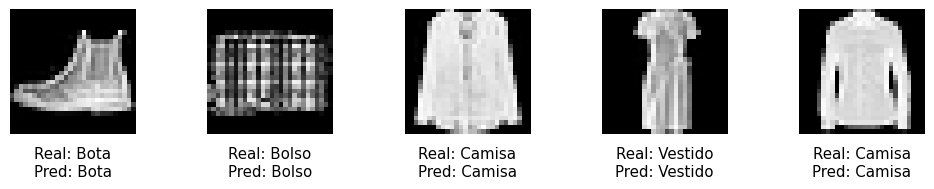

In [81]:
print('Muestra de predicciones en el conjunto de test:')

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

model.eval()

with torch.no_grad():
    # Para asegurar la reproducibilidad, tomamos muestras específicas del test set
    # En lugar de usar random_split, podemos iterar el test_loader o acceder a dataset_test
    # Aquí accedemos directamente al dataset_test para 5 imágenes consecutivas y reproducibles
    torch.manual_seed(42) # para reproducibilidad de las muestras
    sample_indices = torch.randint(0, len(dataset_test), (5,)).tolist()

    for i, idx in enumerate(sample_indices):
        figure.add_subplot(1, 5, i + 1)
        img, label = dataset_test[idx]

        input_img = img.view(1, 28 * 28).to(device)
        output = model(input_img)
        predicted_class = torch.argmax(output).item()

        plt.imshow(img.squeeze(), cmap='Greys_r')
        plt.axis('off')
        plt.title(f"Real: {desc[label]}\nPred: {desc[predicted_class]}", y=-0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [82]:
all_targets = []
all_predictions = []
all_confidences = []

model.eval()

with torch.no_grad():

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = model(
            data.view(data.shape[0], 28 * 28)
        )

        pred = output.argmax(dim=1)
        confidence = output.max(dim=1).values

        all_targets.append(target.cpu())
        all_predictions.append(pred.cpu())
        all_confidences.append(confidence.cpu())

all_targets = torch.cat(all_targets)
all_predictions = torch.cat(all_predictions)
all_confidences = torch.cat(all_confidences)

all_correct = (
    all_predictions == all_targets
)

print(
    f"Datos de test preparados: "
    f"{len(all_targets):,} muestras."
)

Datos de test preparados: 10,000 muestras.


## 06 · Model Intelligence

Más allá de la precisión global, analizamos dónde acierta el modelo,
dónde falla y cuándo una predicción presenta mayor incertidumbre.

### 6.1 Precisión por clase

In [83]:
class_correct = torch.zeros(output_size, dtype=torch.int64)
class_total = torch.zeros(output_size, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data.view(data.shape[0], 28 * 28))
        pred = output.argmax(dim=1)

        # Mover a CPU antes de usar como índice
        target_cpu = target.cpu()
        pred_cpu = pred.cpu()

        for i in range(output_size):
            class_total[i] += (target_cpu == i).sum().item()
            class_correct[i] += ((pred_cpu == i) & (target_cpu == i)).sum().item()

class_accuracy = 100 * class_correct.float() / class_total.float()

print("Precisión por clase en el conjunto de test:")
print("\n| Clase       | Correctos | Total   | Accuracy |")
print("|:------------|:----------|:--------|:---------|")
for i in range(output_size):
    print(f"| {desc[i]:<11} | {class_correct[i].item():<9} | {class_total[i].item():<7} | {class_accuracy[i].item():<8.2f}% |")

best_class_idx = torch.argmax(class_accuracy).item()
worst_class_idx = torch.argmin(class_accuracy).item()

html_panel_class_accuracy = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 220px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">MEJOR RECONOCIDA</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">{desc[best_class_idx]} ({class_accuracy[best_class_idx]:.2f} %)</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 220px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">MAYOR DIFICULTAD</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">{desc[worst_class_idx]} ({class_accuracy[worst_class_idx]:.2f} %)</p>
    </div>
</div>
"""
display(HTML(html_panel_class_accuracy))

Precisión por clase en el conjunto de test:

| Clase       | Correctos | Total   | Accuracy |
|:------------|:----------|:--------|:---------|
| Camiseta/top | 844       | 1000    | 84.40   % |
| Pantalón    | 967       | 1000    | 96.70   % |
| Jersey      | 776       | 1000    | 77.60   % |
| Vestido     | 890       | 1000    | 89.00   % |
| Abrigo      | 840       | 1000    | 84.00   % |
| Sandalia    | 958       | 1000    | 95.80   % |
| Camisa      | 683       | 1000    | 68.30   % |
| Zapatilla   | 950       | 1000    | 95.00   % |
| Bolso       | 970       | 1000    | 97.00   % |
| Bota        | 957       | 1000    | 95.70   % |


### 6.2 Matriz de confusión

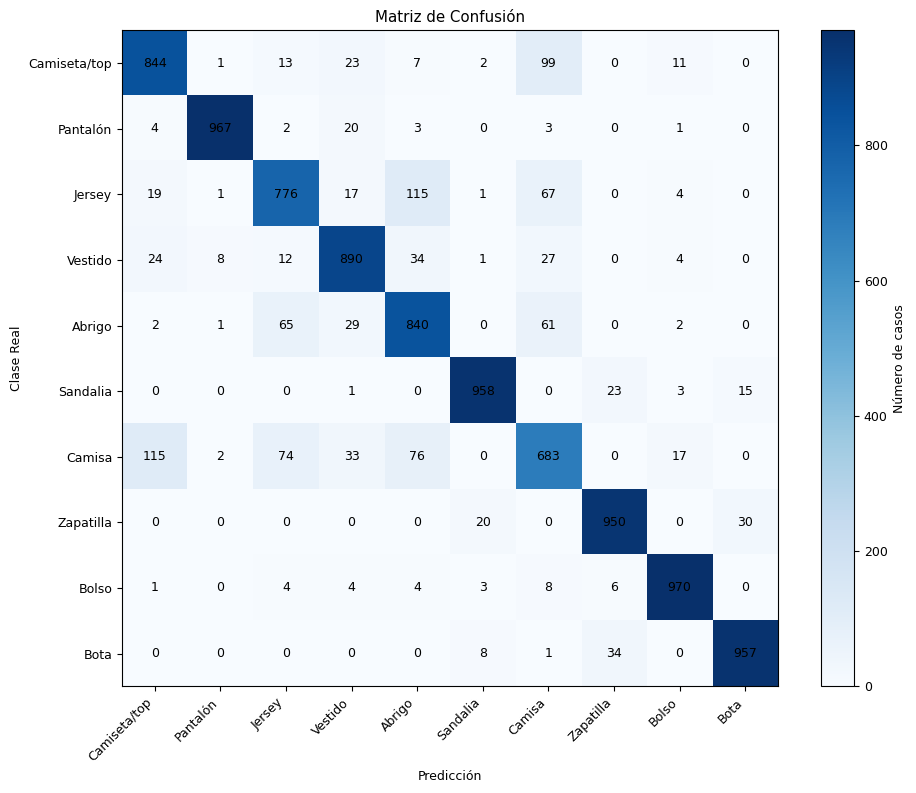

In [84]:
confusion = torch.zeros(output_size, output_size, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data.view(data.shape[0], 28 * 28))
        pred = output.argmax(dim=1)

        # Mover a CPU antes de usar como índice
        target_cpu = target.cpu()
        pred_cpu = pred.cpu()

        for t, p in zip(target_cpu.view(-1), pred_cpu.view(-1)):
            confusion[t.long(), p.long()] += 1

plt.figure(figsize=(10, 8))
plt.imshow(confusion, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.xticks(range(output_size), desc, rotation=45, ha='right')
plt.yticks(range(output_size), desc)
plt.colorbar(label='Número de casos')

# Añadir valores numéricos a la matriz
for i in range(output_size):
    for j in range(output_size):
        plt.text(j, i, confusion[i, j].item(), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [85]:
confusion_copy = confusion.clone()
# Poner la diagonal a cero para encontrar las confusiones
for i in range(output_size):
    confusion_copy[i, i] = 0

# Obtener las 3 confusiones más frecuentes
# Flatten the matrix to find top values and their original indices
flat_confusion = confusion_copy.view(-1)
top_k_values, top_k_indices = torch.topk(flat_confusion, 3)

print("Top 3 confusiones más frecuentes:")
for i in range(3):
    value = top_k_values[i].item()
    idx = top_k_indices[i].item()
    real_class = idx // output_size
    predicted_class = idx % output_size
    print(f"{i+1}. {desc[real_class]} → {desc[predicted_class]}: {value} casos")

Top 3 confusiones más frecuentes:
1. Camisa → Camiseta/top: 115 casos
2. Jersey → Abrigo: 115 casos
3. Camiseta/top → Camisa: 99 casos


### 6.3 Prediction Confidence

In [86]:
def confidence_level(confidence):
    if confidence >= 0.80:
        return "Alta"
    elif confidence >= 0.60:
        return "Media"
    else:
        return "Baja · revisar"

print('Muestra de predicciones con niveles de confianza:')

model.eval()
with torch.no_grad():
    torch.manual_seed(43) # Otra semilla para reproducibilidad de esta sección
    sample_indices = torch.randint(0, len(dataset_test), (5,)).tolist()

    for idx in sample_indices:
        img, label = dataset_test[idx]
        input_img = img.view(1, 28 * 28).to(device)
        output = model(input_img) # output ya contiene probabilidades Softmax

        # Get top 2 predictions and their probabilities
        top_k_probs, top_k_indices = torch.topk(output, k=2, dim=1)

        top1_prob = top_k_probs[0, 0].item()
        top1_pred = top_k_indices[0, 0].item()

        top2_prob = top_k_probs[0, 1].item()
        top2_pred = top_k_indices[0, 1].item()

        print(f"\nReal: {desc[label]}")
        print(f"Top-1: {desc[top1_pred]}")
        print(f"Confianza: {top1_prob:.2%} ") # Mostrar como porcentaje
        print(f"Nivel: {confidence_level(top1_prob)}")
        print(f"Top-2: {desc[top2_pred]}")
        print(f"Confianza Top-2: {top2_prob:.2%}") # Mostrar como porcentaje

Muestra de predicciones con niveles de confianza:

Real: Pantalón
Top-1: Pantalón
Confianza: 100.00% 
Nivel: Alta
Top-2: Vestido
Confianza Top-2: 0.00%

Real: Bolso
Top-1: Vestido
Confianza: 70.04% 
Nivel: Media
Top-2: Camiseta/top
Confianza Top-2: 26.15%

Real: Sandalia
Top-1: Sandalia
Confianza: 99.49% 
Nivel: Alta
Top-2: Vestido
Confianza Top-2: 0.14%

Real: Bolso
Top-1: Bolso
Confianza: 99.34% 
Nivel: Alta
Top-2: Abrigo
Confianza Top-2: 0.59%

Real: Bota
Top-1: Bota
Confianza: 99.80% 
Nivel: Alta
Top-2: Zapatilla
Confianza Top-2: 0.19%


Los niveles son un criterio demostrativo de interpretación de las
probabilidades Softmax y no modifican el entrenamiento ni la clasificación.

### 6.4 Smart Review

In [87]:
def group_metrics(mask):
    total = mask.sum().item()

    if total == 0:
        return 0, 0.0, 0.0

    correct = all_correct[mask].sum().item()

    percentage = 100.0 * total / len(all_targets)
    accuracy = 100.0 * correct / total

    return total, percentage, accuracy


high_mask = all_confidences >= 0.80
medium_mask = (
    (all_confidences >= 0.60) &
    (all_confidences < 0.80)
)
review_mask = all_confidences < 0.60

high_total, high_percent, high_accuracy = group_metrics(high_mask)
medium_total, medium_percent, medium_accuracy = group_metrics(medium_mask)
review_total, review_percent, review_accuracy = group_metrics(review_mask)

html_panel_smart_review = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ALTA CONFIANZA</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{high_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{high_percent:.1f} % del test</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {high_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CONFIANZA MEDIA</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{medium_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{medium_percent:.1f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {medium_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">REVISAR</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{review_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{review_percent:.1f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {review_accuracy:.2f} %</p>
    </div>
</div>
"""
display(HTML(html_panel_smart_review))

Smart Review permite identificar las predicciones de menor confianza que
podrían beneficiarse de una revisión adicional.

Las probabilidades Softmax se utilizan como indicador de confianza del
modelo; no se afirma que estén estadísticamente calibradas.

5 Casos Erróneos en el conjunto de Test:


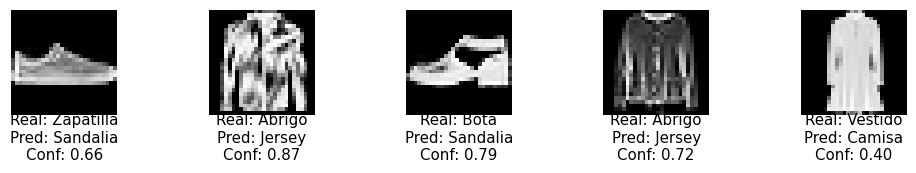

In [88]:
print('5 Casos Erróneos en el conjunto de Test:')

# Obtener los índices de los casos erróneos
error_indices = (
    all_predictions != all_targets
).nonzero(as_tuple=True)[0][:5]

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

for i, idx in enumerate(error_indices):
    figure.add_subplot(1, 5, i + 1)

    img, _ = dataset_test[idx.item()] # Obtener la imagen del dataset original

    real_label = all_targets[idx].item()
    predicted_label = all_predictions[idx].item()
    confidence = all_confidences[idx].item()

    plt.imshow(img.squeeze(), cmap='Greys_r')
    plt.axis('off')
    plt.title(f"Real: {desc[real_label]}\nPred: {desc[predicted_label]}\nConf: {confidence:.2f}", y=-0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 07 · Conclusión

### 7.1 · Aplicabilidad de lo aprendido

El principal aprendizaje de esta actividad no se limita a clasificar prendas de FashionMNIST. Comprender el ciclo completo de construcción y evaluación de un modelo de clasificación —que incluye: Datos → Preprocesamiento → Entrenamiento → Validación → Selección del mejor modelo → Test → Interpretación → Decisión— es la clave. Esta metodología puede transferirse conceptualmente a diversos problemas de clasificación con categorías predefinidas, como la clasificación de productos, la inspección visual para control de calidad, la identificación de defectos, la clasificación documental, el reconocimiento de patrones o la creación de sistemas de priorización para revisión humana. Este modelo, si bien no es directamente utilizable en estas aplicaciones sin una validación exhaustiva, sienta las bases metodológicas para su desarrollo.

### 7.3 · Conclusión final

Este ejercicio ha demostrado el ciclo completo de desarrollo de un modelo de clasificación con una MLP de arquitectura 784 → 512 → 256 → 128 → 10. La rigurosa separación en conjuntos de Train, Validation y Test fue esencial para seleccionar el mejor estado del modelo, que superó el 89 % de precisión en validación. El análisis de errores, la matriz de confusión y la precisión por clase permitieron identificar las categorías más desafiantes. Además, conceptos como Smart Review y Accuracy vs Coverage proporcionaron una interpretación práctica de las predicciones, vinculando la confianza del modelo con posibles reglas de decisión. Este proceso subraya que, aunque el modelo de FashionMNIST no esté listo para producción, la metodología es aplicable. El principal aprendizaje no fue únicamente entrenar una red neuronal, sino comprender el ciclo que conecta los datos, el modelo, la validación, la interpretación y una posible aplicación futura.